# Convolutional Neural Network (CNN) Algorithm

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data import Subset
import numpy as np
import copy

In [15]:
def get_transforms(use_augmentation=False):

    transform_base = [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),
                             (0.5, 0.5, 0.5))
    ]

    # Train Transform
    if use_augmentation:
        transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            transforms.RandomRotation(15),
            *transform_base
        ])
    else:
        transform_train = transforms.Compose(transform_base)

    # Evaluation Transform
    transform_eval = transforms.Compose(transform_base)

    return transform_train, transform_eval

In [3]:
def get_datasets(val_split=0.2, use_augmentation=False, seed=42):

    transform_train, transform_eval = get_transforms(use_augmentation)

    # Full dataset for train and evaluation
    full_dataset_train = CIFAR10(
        root='./data',
        train=True,
        transform=transform_train,
        download=True
    )

    full_dataset_eval = CIFAR10(
        root='./data',
        train=True,
        transform=transform_eval,
        download=False
    )

    dataset_size = len(full_dataset_train)
    train_size = int((1 - val_split) * dataset_size)

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(dataset_size, generator=generator)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_dataset_train, train_indices)
    val_dataset   = Subset(full_dataset_eval,  val_indices)

    # Test dataset
    test_dataset = CIFAR10(
        root='./data',
        train=False,
        transform=transform_eval,
        download=True
    )

    return train_dataset, val_dataset, test_dataset

In [4]:
def get_dataloaders(batch_size=64, val_split=0.2, use_augmentation=False, seed=42):

    train_dataset, val_dataset, test_dataset = get_datasets(
        val_split=val_split,
        use_augmentation=use_augmentation,
        seed=seed
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return train_loader, val_loader, test_loader

In [5]:
def train_model(model, train_loader, val_loader,
                optimizer, criterion,
                epochs=10,
                device='cuda',
                patience=3):

    model.to(device)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):

        # Training
        model.train()

        train_loss_total = 0
        correct, total = 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss_total += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = train_loss_total / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()

        val_loss_total = 0
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_total += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = val_loss_total / len(val_loader)
        val_acc = correct / total


        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} || "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            break

    # restore best model
    model.load_state_dict(best_model_state)

    return train_losses, val_losses, train_accs, val_accs

In [6]:
def evaluate_model(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    return test_acc

In [7]:
def per_class_accuracy(model, dataloader, device='cuda'):
    model.to(device)
    model.eval()

    num_classes = 10
    correct = np.zeros(num_classes)
    total = np.zeros(num_classes)

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(len(labels)):
                label = labels[i].item()
                pred = preds[i].item()

                if label == pred:
                    correct[label] += 1
                total[label] += 1

    acc_per_class = correct / total
    return acc_per_class

In [8]:
def plot_class_accuracy(acc_per_class):

    classes = [
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck"
    ]

    plt.figure()
    plt.bar(classes, acc_per_class)
    plt.xticks(rotation=45)
    plt.ylabel("Accuracy")
    plt.title("Accuracy per Class")
    plt.show()

## Set of experiments 1 - Architectures

* Fixed Optimizer as Adam
* Fixed Dropout as 0.0
* Without Data Augmentation

* Learning rate = 0.001
* Number of epochs = 10
* Patience = 3

In [9]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset, val_dataset, test_dataset = get_datasets(
    val_split=0.2, use_augmentation=False, seed=42)

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=64, val_split=0.2, use_augmentation=False, seed=42)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train dataset size: 40000
Validation dataset size: 10000
Test dataset size: 10000


### Architecture 1 - like LeNet-5

[conv(32, 5x5) → relu → pool]
[conv(64, 5x5) → relu → pool]
[FC(200) → FC(150) → output]

In [ ]:
class CNN1(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(CNN1, self).__init__()
        # CIFAR-10: 32x32 images with 3 color channels (RGB)
        # Input: (3, 32, 32)

        # First convolutional layer: 3 input channels, 32 output channels, kernel size 5
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5) # Output: (32, 28, 28)
        # Max pooling layer with kernel size 2 and stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (32, 14, 14)

        # Second convolutional layer: 32 input channels, 64 output channels, kernel size 5
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5) # Output: (64, 10, 10)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 5, 5)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 5 * 5, 200) # FC1: 64*5*5 -> 200
        self.fc2 = nn.Linear(200, 150) # FC2: 200 -> 150
        self.fc3 = nn.Linear(150, num_classes) # FC3: 150 -> num_classes

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # First Layer
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        # Second Layer
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Flatten: [Batch_size, 64, 5, 5] -> [Batch_size, 64*5*5]
        x = x.view(-1, 64 * 5 * 5)

        # Fully Connected Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [ ]:
model = CNN1(num_classes=10, dropout=0.1)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_1, val_losses_1, train_accs_1, val_accs_1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/20] Train Loss: 1.6254 | Train Acc: 0.3976 || Val Loss: 1.3426 | Val Acc: 0.5069
Epoch [2/20] Train Loss: 1.2877 | Train Acc: 0.5387 || Val Loss: 1.1264 | Val Acc: 0.5928
Epoch [3/20] Train Loss: 1.1334 | Train Acc: 0.6002 || Val Loss: 1.0301 | Val Acc: 0.6351
Epoch [4/20] Train Loss: 1.0297 | Train Acc: 0.6380 || Val Loss: 0.9769 | Val Acc: 0.6536
Epoch [5/20] Train Loss: 0.9462 | Train Acc: 0.6691 || Val Loss: 0.9552 | Val Acc: 0.6640
Epoch [6/20] Train Loss: 0.8776 | Train Acc: 0.6938 || Val Loss: 0.9173 | Val Acc: 0.6793
Epoch [7/20] Train Loss: 0.8181 | Train Acc: 0.7140 || Val Loss: 0.9130 | Val Acc: 0.6851
Epoch [8/20] Train Loss: 0.7658 | Train Acc: 0.7335 || Val Loss: 0.8847 | Val Acc: 0.6952
Epoch [9/20] Train Loss: 0.7164 | Train Acc: 0.7476 || Val Loss: 0.8943 | Val Acc: 0.6932
Epoch [10/20] Train Loss: 0.6780 | Train Acc: 0.7611 || Val Loss: 0.8881 | Val Acc: 0.6961
Epoch [11/20] Train Loss: 0.6409 | Train Acc: 0.7744 || Val Loss: 0.8728 | Val Acc: 0.7043
Epoch [1

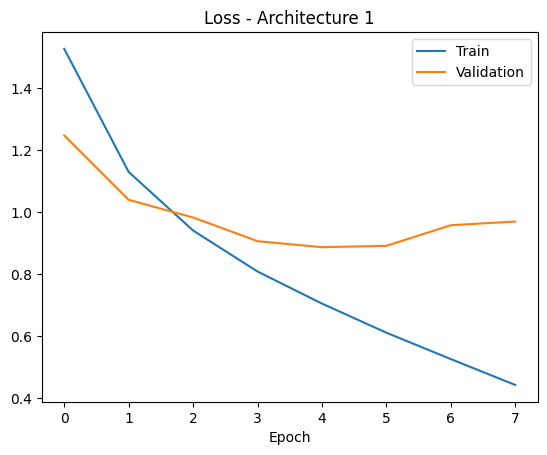

In [40]:
plt.plot(train_losses_1, label='Train')
plt.plot(val_losses_1, label='Validation')
plt.legend()
plt.title('Loss - Architecture 1')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.6961


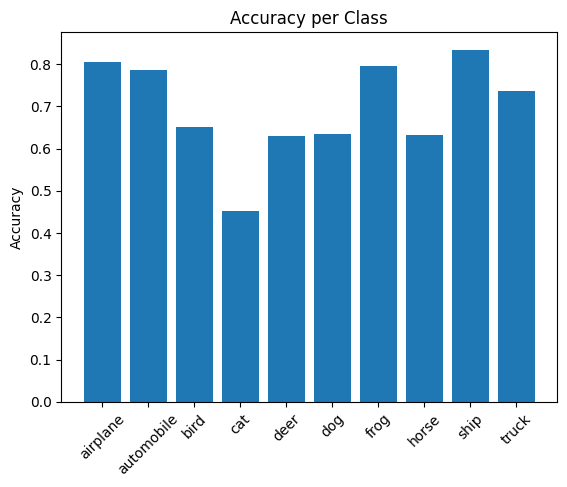

In [41]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

### Architecture 2 - High Width

[conv(64, 5x5) → relu → pool]
[conv(128, 3x3) → relu → pool]
[FC(200) → FC(150) → output]

In [42]:
class CNN2(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(CNN2, self).__init__()
        # CIFAR-10: 32x32 images with 3 color channels (RGB)
        # Input: (3, 32, 32)

        # First convolutional layer: 3 input channels, 64 output channels, kernel size 5
        self.conv1 = nn.Conv2d(3, 64, kernel_size=5) # Output: (64, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 14, 14)

        # Second convolutional layer: 64 input channels, 128 output channels, kernel size 3
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3) # Output: (128, 12, 12)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 6, 6)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 6 * 6, 200) # FC1: 128*6*6 -> 200
        self.fc2 = nn.Linear(200, 150) # FC2: 200 -> 150
        self.fc3 = nn.Linear(150, num_classes) # FC3: 150 -> num_classes

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        # Flatten: [Batch_size, 128, 6, 6] -> [Batch_size, 128*6*6]
        x = x.view(-1, 128 * 6 * 6)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [43]:
model = CNN2(num_classes=10, dropout=0.0)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_2, val_losses_2, train_accs_2, val_accs_2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.4104 | Train Acc: 0.4885 || Val Loss: 1.1144 | Val Acc: 0.6012
Epoch [2/10] Train Loss: 0.9941 | Train Acc: 0.6474 || Val Loss: 0.9706 | Val Acc: 0.6623
Epoch [3/10] Train Loss: 0.8125 | Train Acc: 0.7157 || Val Loss: 0.8437 | Val Acc: 0.7053
Epoch [4/10] Train Loss: 0.6593 | Train Acc: 0.7686 || Val Loss: 0.8254 | Val Acc: 0.7201
Epoch [5/10] Train Loss: 0.5225 | Train Acc: 0.8149 || Val Loss: 0.8627 | Val Acc: 0.7132
Epoch [6/10] Train Loss: 0.4000 | Train Acc: 0.8594 || Val Loss: 0.9633 | Val Acc: 0.6981
Epoch [7/10] Train Loss: 0.2979 | Train Acc: 0.8950 || Val Loss: 1.0218 | Val Acc: 0.7134


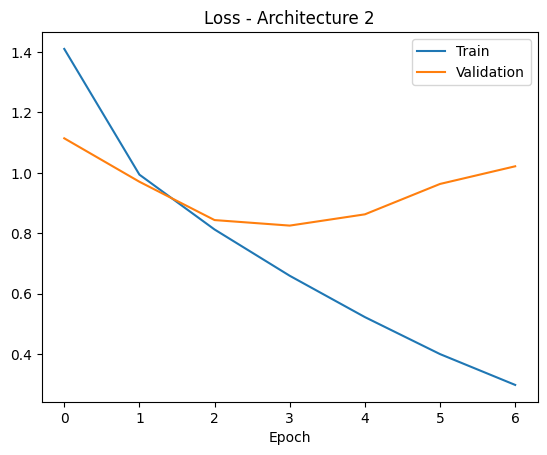

In [44]:
plt.plot(train_losses_2, label='Train')
plt.plot(val_losses_2, label='Validation')
plt.legend()
plt.title('Loss - Architecture 2')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7130


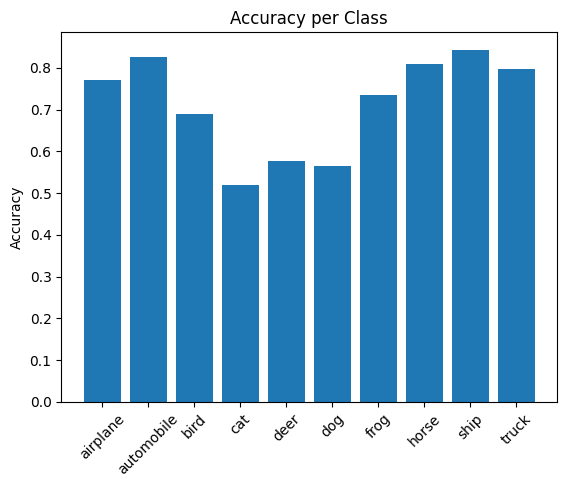

In [45]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

### Architecture 3 - Depth

[conv(32, 5x5) → relu → pool]
[conv(64, 5x5) → relu → pool]
[conv(128, 3x3) → relu → pool]
[FC(200) → FC(150) → output]

In [46]:
class CNN3(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(CNN3, self).__init__()
        # CIFAR-10: 32x32 images with 3 color channels (RGB)
        # Input: (3, 32, 32)

        # First convolutional layer: 3 input channels, 32 output channels, kernel size 5
        self.conv1 = nn.Conv2d(3, 32, kernel_size=5, padding=0, stride=1) # Output: (32, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (32, 14, 14)
        
        # Second convolutional layer: 32 input channels, 64 output channels, kernel size 3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0, stride=1) # Output: (64, 12, 12)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 6, 6)

        # Third convolutional layer: 64 input channels, 128 output channels, kernel size 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=0, stride=1) # Output: (128, 4, 4)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 2, 2)

        self.fc1 = nn.Linear(128 * 2 * 2, 200) # FC1: 128*2*2 -> 200
        self.fc2 = nn.Linear(200, num_classes) # FC2: 200 -> num_classes

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        # Flatten: [Batch_size, 128, 2, 2] -> [Batch_size, 128*2*2]
        x = x.view(-1, 128 * 2 * 2)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [47]:
model = CNN3(num_classes=10, dropout=0.0)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_3, val_losses_3, train_accs_3, val_accs_3 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.5765 | Train Acc: 0.4199 || Val Loss: 1.3259 | Val Acc: 0.5181
Epoch [2/10] Train Loss: 1.2181 | Train Acc: 0.5641 || Val Loss: 1.1208 | Val Acc: 0.5895
Epoch [3/10] Train Loss: 1.0404 | Train Acc: 0.6308 || Val Loss: 1.0551 | Val Acc: 0.6279
Epoch [4/10] Train Loss: 0.9155 | Train Acc: 0.6767 || Val Loss: 0.9057 | Val Acc: 0.6764
Epoch [5/10] Train Loss: 0.8093 | Train Acc: 0.7157 || Val Loss: 0.8710 | Val Acc: 0.6947
Epoch [6/10] Train Loss: 0.7311 | Train Acc: 0.7451 || Val Loss: 0.8284 | Val Acc: 0.7090
Epoch [7/10] Train Loss: 0.6599 | Train Acc: 0.7689 || Val Loss: 0.8609 | Val Acc: 0.7033
Epoch [8/10] Train Loss: 0.5964 | Train Acc: 0.7903 || Val Loss: 0.8705 | Val Acc: 0.7074
Epoch [9/10] Train Loss: 0.5337 | Train Acc: 0.8136 || Val Loss: 0.8760 | Val Acc: 0.7073


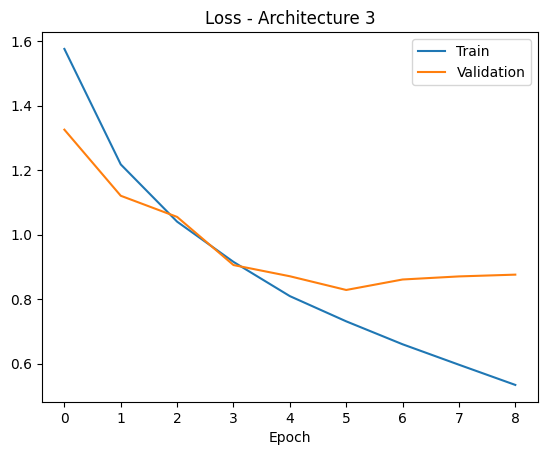

In [48]:
plt.plot(train_losses_3, label='Train')
plt.plot(val_losses_3, label='Validation')
plt.legend()
plt.title('Loss - Architecture 3')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7049


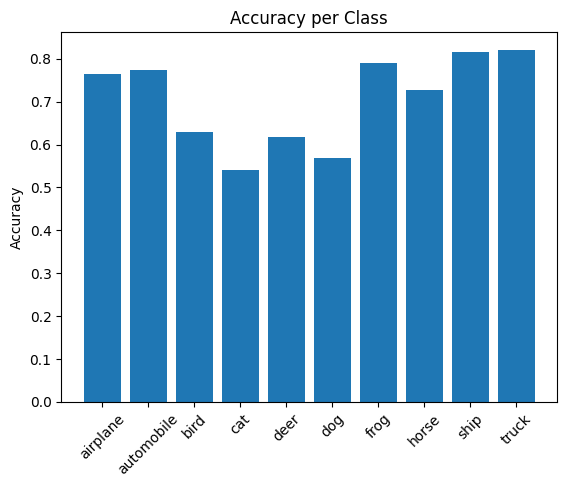

In [49]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

### Architecture 4 - like VGG

[conv(64, 3x3) → relu → conv(64, 3x3) → relu → pool]
[conv(128, 3x3) → relu → conv(128, 3x3) → relu → pool]
[FC(200) → output]

In [11]:
class CNN4(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(CNN4, self).__init__()
        # CIFAR-10: 32x32 images with 3 color channels (RGB)
        # Input: (3, 32, 32)

        # First convolutional layer: 3 input channels, 32 output channels, kernel size 5
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=0, stride=1) # Output: (64, 30, 30)

        # Second convolutional layer: 64 input channels, 64 output channels, kernel size 3
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=0, stride=1) # Output: (64, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 14, 14)

        # Third convolutional layer: 64 input channels, 128 output channels, kernel size 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=0, stride=1) # Output: (128, 12, 12)

        # Fourth convolutional layer: 128 input channels, 128 output channels, kernel size 3
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=0, stride=1) # Output: (128, 10, 10)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 5, 5)

        self.fc1 = nn.Linear(128 * 5 * 5, 200) # FC1: 128*5*5 -> 200
        self.fc2 = nn.Linear(200, num_classes) # FC2: 200 -> num_classes

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        # Flatten: [Batch_size, 128, 5, 5] -> [Batch_size, 128*5*5]
        x = x.view(-1, 128 * 5 * 5)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [51]:
model = CNN4(num_classes=10, dropout=0.0)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_4, val_losses_4, train_accs_4, val_accs_4 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.4929 | Train Acc: 0.4560 || Val Loss: 1.1765 | Val Acc: 0.5780
Epoch [2/10] Train Loss: 1.0216 | Train Acc: 0.6394 || Val Loss: 0.9058 | Val Acc: 0.6785
Epoch [3/10] Train Loss: 0.8084 | Train Acc: 0.7163 || Val Loss: 0.7768 | Val Acc: 0.7229
Epoch [4/10] Train Loss: 0.6650 | Train Acc: 0.7674 || Val Loss: 0.8235 | Val Acc: 0.7152
Epoch [5/10] Train Loss: 0.5498 | Train Acc: 0.8076 || Val Loss: 0.7771 | Val Acc: 0.7311
Epoch [6/10] Train Loss: 0.4489 | Train Acc: 0.8422 || Val Loss: 0.8358 | Val Acc: 0.7234


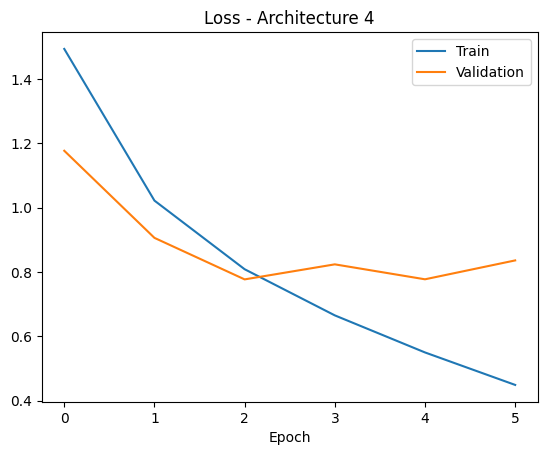

In [52]:
plt.plot(train_losses_4, label='Train')
plt.plot(val_losses_4, label='Validation')
plt.legend()
plt.title('Loss - Architecture 4')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7208


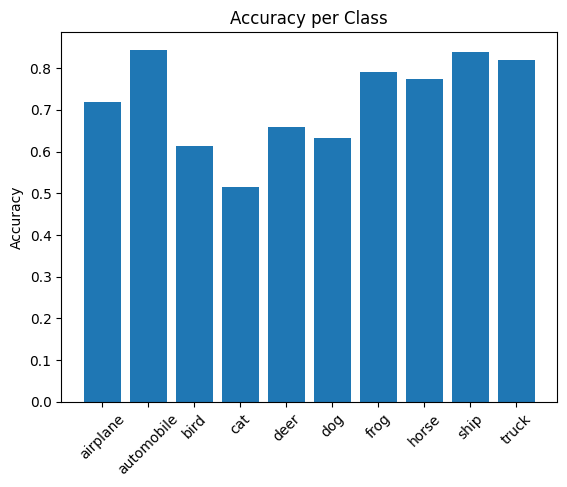

In [53]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

### Architecture 5 - Less Pooling
[conv(64,3x3) → relu]
[conv(128,3x3) → relu]
[pool]
[FC(200) → FC(150) → output]

In [54]:
class CNN5(nn.Module):
    def __init__(self, num_classes=10, dropout=0.0):
        super(CNN5, self).__init__()
        # CIFAR-10: 32x32 images with 3 color channels (RGB)
        # Input: (3, 32, 32)

        # First convolutional layer: 3 input channels, 64 output channels, kernel size 5
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=0) # Output: (64, 30, 30)

        # Second convolutional layer: 64 input channels, 128 output channels, kernel size 3
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=0) # Output: (128, 28, 28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 14, 14)

        self.fc1 = nn.Linear(128 * 14 * 14, 200) # FC1: 128*14*14 -> 200
        self.fc2 = nn.Linear(200, 150) # FC2: 200 -> 150
        self.fc3 = nn.Linear(150, num_classes) # FC3: 150 -> num_classes

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.conv1(x))

        x = F.relu(self.conv2(x))

        x = self.pool1(x)

        # Flatten: [Batch_size, 128, 14, 14] -> [Batch_size, 128*14*14]
        x = x.view(-1, 128 * 14 * 14)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

In [55]:
model = CNN5(num_classes=10, dropout=0.0)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_5, val_losses_5, train_accs_5, val_accs_5 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.3677 | Train Acc: 0.5041 || Val Loss: 1.0676 | Val Acc: 0.6163
Epoch [2/10] Train Loss: 0.9222 | Train Acc: 0.6732 || Val Loss: 0.9418 | Val Acc: 0.6622
Epoch [3/10] Train Loss: 0.6897 | Train Acc: 0.7584 || Val Loss: 0.8930 | Val Acc: 0.6958
Epoch [4/10] Train Loss: 0.4811 | Train Acc: 0.8324 || Val Loss: 1.0174 | Val Acc: 0.6854
Epoch [5/10] Train Loss: 0.2944 | Train Acc: 0.8998 || Val Loss: 1.0793 | Val Acc: 0.6881
Epoch [6/10] Train Loss: 0.1663 | Train Acc: 0.9420 || Val Loss: 1.3279 | Val Acc: 0.6945


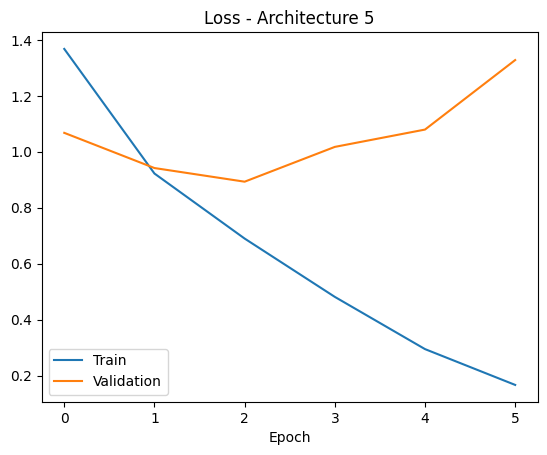

In [56]:
plt.plot(train_losses_5, label='Train')
plt.plot(val_losses_5, label='Validation')
plt.legend()
plt.title('Loss - Architecture 5')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.6891


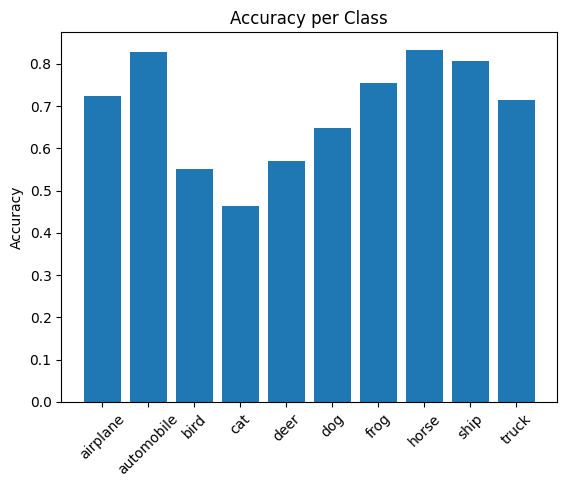

In [57]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

## Set of experiments 2 - Regularization

* Fixed Optimizer as Adam
* Architecure 4
* Without Data Augmentation

* Learning rate = 0.001
* Number of epochs = 10
* Patience = 3

### Dropout = 0.1

In [58]:
model = CNN4(num_classes=10, dropout=0.1)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_dp01, val_losses_dp01, train_accs_dp01, val_accs_dp01 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.5279 | Train Acc: 0.4390 || Val Loss: 1.2077 | Val Acc: 0.5595
Epoch [2/10] Train Loss: 1.0782 | Train Acc: 0.6151 || Val Loss: 0.8999 | Val Acc: 0.6766
Epoch [3/10] Train Loss: 0.8540 | Train Acc: 0.6984 || Val Loss: 0.8102 | Val Acc: 0.7119
Epoch [4/10] Train Loss: 0.7127 | Train Acc: 0.7470 || Val Loss: 0.7527 | Val Acc: 0.7387
Epoch [5/10] Train Loss: 0.6101 | Train Acc: 0.7834 || Val Loss: 0.7483 | Val Acc: 0.7509
Epoch [6/10] Train Loss: 0.5139 | Train Acc: 0.8181 || Val Loss: 0.7074 | Val Acc: 0.7556
Epoch [7/10] Train Loss: 0.4342 | Train Acc: 0.8461 || Val Loss: 0.7193 | Val Acc: 0.7627
Epoch [8/10] Train Loss: 0.3731 | Train Acc: 0.8668 || Val Loss: 0.7580 | Val Acc: 0.7639
Epoch [9/10] Train Loss: 0.3082 | Train Acc: 0.8894 || Val Loss: 0.8497 | Val Acc: 0.7629


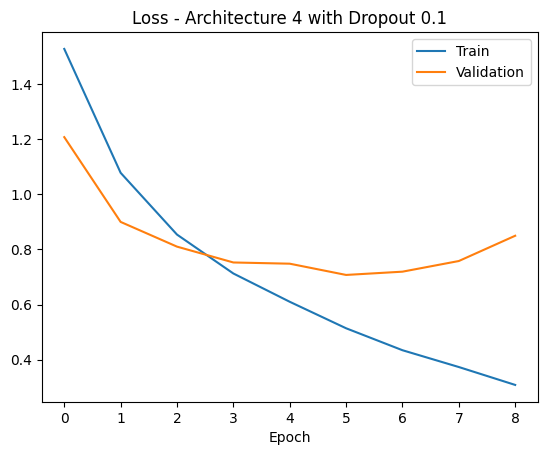

In [59]:
plt.plot(train_losses_dp01, label='Train')
plt.plot(val_losses_dp01, label='Validation')
plt.legend()
plt.title('Loss - Architecture 4 with Dropout 0.1')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7570


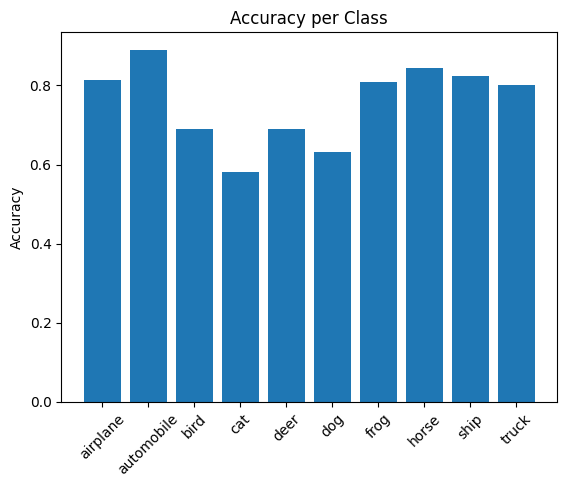

In [60]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

### Dropout = 0.3

In [61]:
model = CNN4(num_classes=10, dropout=0.3)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_dp03, val_losses_dp03, train_accs_dp03, val_accs_dp03 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.5833 | Train Acc: 0.4150 || Val Loss: 1.2568 | Val Acc: 0.5462
Epoch [2/10] Train Loss: 1.1880 | Train Acc: 0.5757 || Val Loss: 1.0099 | Val Acc: 0.6400
Epoch [3/10] Train Loss: 1.0064 | Train Acc: 0.6455 || Val Loss: 0.9050 | Val Acc: 0.6765
Epoch [4/10] Train Loss: 0.8783 | Train Acc: 0.6926 || Val Loss: 0.8794 | Val Acc: 0.6912
Epoch [5/10] Train Loss: 0.7902 | Train Acc: 0.7227 || Val Loss: 0.7972 | Val Acc: 0.7194
Epoch [6/10] Train Loss: 0.7137 | Train Acc: 0.7491 || Val Loss: 0.7831 | Val Acc: 0.7309
Epoch [7/10] Train Loss: 0.6478 | Train Acc: 0.7731 || Val Loss: 0.7706 | Val Acc: 0.7320
Epoch [8/10] Train Loss: 0.5923 | Train Acc: 0.7896 || Val Loss: 0.7492 | Val Acc: 0.7450
Epoch [9/10] Train Loss: 0.5449 | Train Acc: 0.8064 || Val Loss: 0.7530 | Val Acc: 0.7471
Epoch [10/10] Train Loss: 0.4951 | Train Acc: 0.8230 || Val Loss: 0.7524 | Val Acc: 0.7478


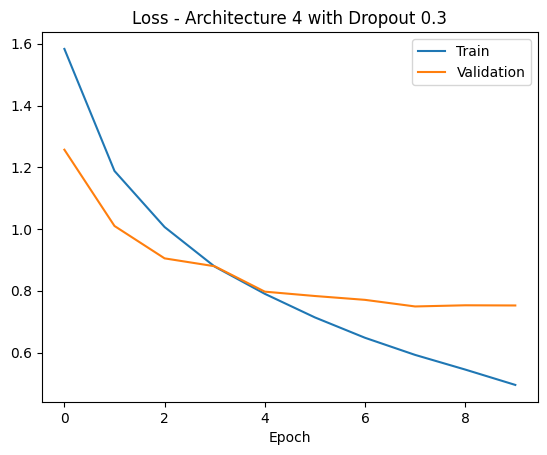

In [62]:
plt.plot(train_losses_dp03, label='Train')
plt.plot(val_losses_dp03, label='Validation')
plt.legend()
plt.title('Loss - Architecture 4 with Dropout 0.3')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7416


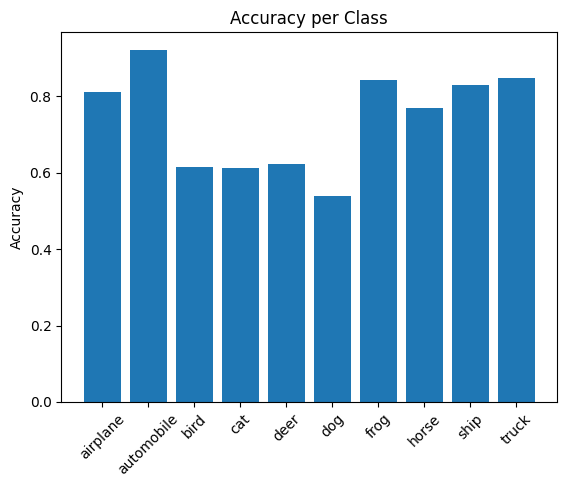

In [63]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

## Set of experiments 3 - Data Augmentation

* Fixed Optimizer as Adam
* Architecure 4
* Dropout = 0.1

* Learning rate = 0.001
* Number of epochs = 10
* Patience = 3

In [18]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset, val_dataset, test_dataset = get_datasets(
    val_split=0.2, use_augmentation=True, seed=42)

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=64, val_split=0.2, use_augmentation=True, seed=42)

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Train dataset size: 40000
Validation dataset size: 10000
Test dataset size: 10000


In [12]:
model = CNN4(num_classes=10, dropout=0.1)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses_daug, val_losses_daug, train_accs_daug, val_accs_daug = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=10,
    device=device
)

Epoch [1/10] Train Loss: 1.6685 | Train Acc: 0.3779 || Val Loss: 1.3022 | Val Acc: 0.5330
Epoch [2/10] Train Loss: 1.2747 | Train Acc: 0.5400 || Val Loss: 1.0529 | Val Acc: 0.6222
Epoch [3/10] Train Loss: 1.0898 | Train Acc: 0.6098 || Val Loss: 0.9126 | Val Acc: 0.6764
Epoch [4/10] Train Loss: 0.9679 | Train Acc: 0.6562 || Val Loss: 0.8061 | Val Acc: 0.7157
Epoch [5/10] Train Loss: 0.8840 | Train Acc: 0.6896 || Val Loss: 0.7454 | Val Acc: 0.7339
Epoch [6/10] Train Loss: 0.8263 | Train Acc: 0.7097 || Val Loss: 0.7090 | Val Acc: 0.7487
Epoch [7/10] Train Loss: 0.7739 | Train Acc: 0.7279 || Val Loss: 0.7155 | Val Acc: 0.7440
Epoch [8/10] Train Loss: 0.7424 | Train Acc: 0.7401 || Val Loss: 0.6576 | Val Acc: 0.7717
Epoch [9/10] Train Loss: 0.7159 | Train Acc: 0.7499 || Val Loss: 0.6672 | Val Acc: 0.7655
Epoch [10/10] Train Loss: 0.6867 | Train Acc: 0.7595 || Val Loss: 0.6165 | Val Acc: 0.7870


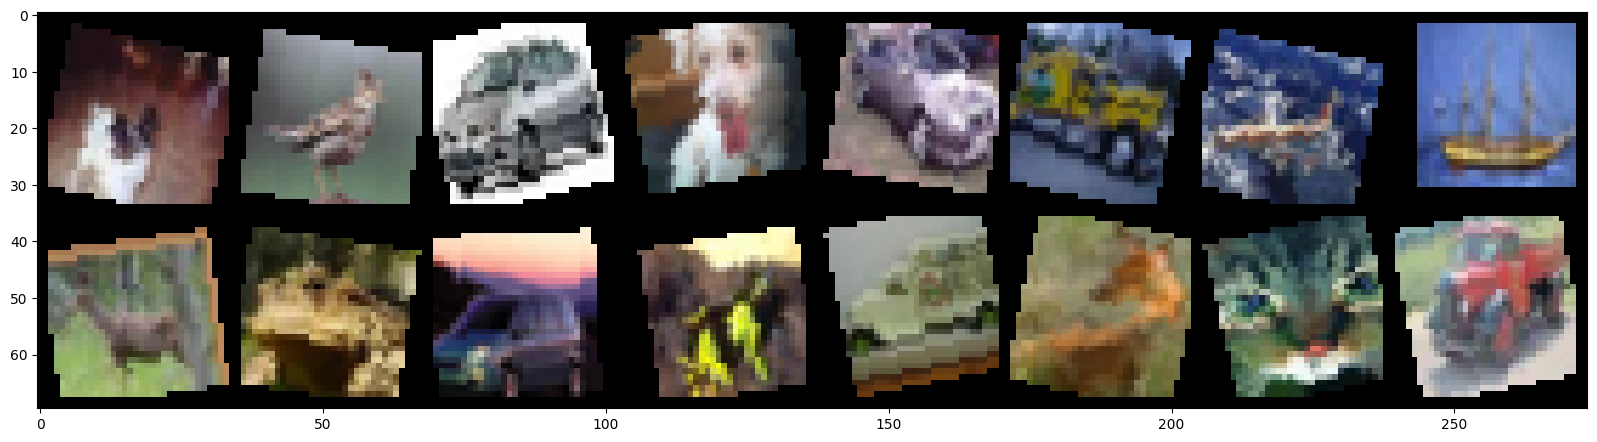

In [19]:
import torchvision

plt.figure(figsize = (20,10))
images, labels = next(iter(train_loader))
out = torchvision.utils.make_grid(images[0:16], normalize=True)
_ = plt.imshow(out.numpy().transpose((1, 2, 0)))

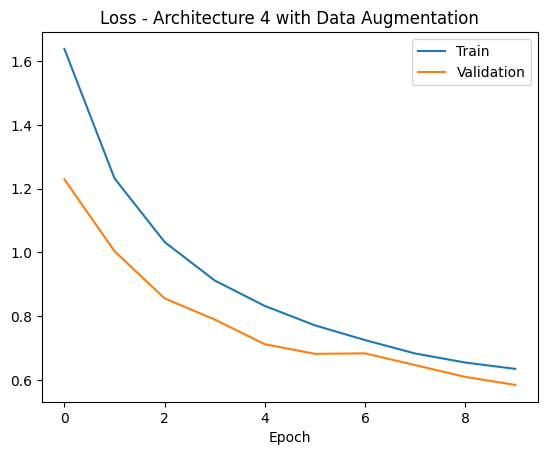

In [17]:
plt.plot(train_losses_daug, label='Train')
plt.plot(val_losses_daug, label='Validation')
plt.legend()
plt.title('Loss - Architecture 4 with Data Augmentation')
plt.xlabel('Epoch')
plt.show()

Test Accuracy: 0.7776


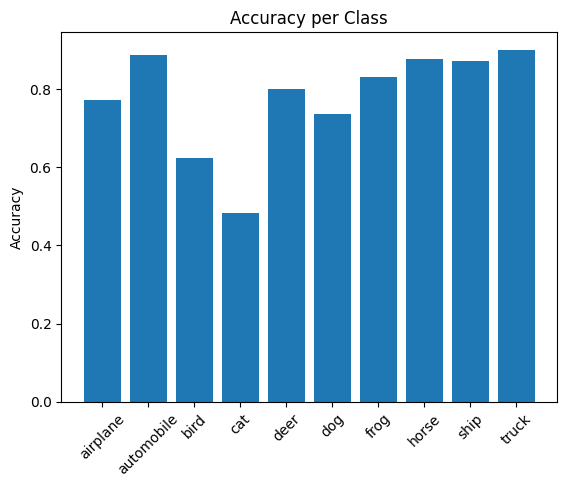

In [67]:
evaluate_model(model, test_loader, device=device)

acc_per_class = per_class_accuracy(model, test_loader, device=device)
plot_class_accuracy(acc_per_class)

In [58]:
def plot_filters(model):

    conv_count = 0

    for layer in model.modules():

        if isinstance(layer, nn.Conv2d):

            conv_count += 1

            weights = layer.weight.data.cpu().numpy()

            num_filters = min(weights.shape[0], 16)

            plt.figure(figsize=(8,4))

            for i in range(num_filters):

                kernel = weights[i].mean(axis=0)

                kernel = (kernel - kernel.min()) / (
                    kernel.max() - kernel.min() + 1e-8
                )

                plt.subplot(2, 8, i+1)

                plt.imshow(kernel, cmap='gray')

                plt.axis('off')

            plt.suptitle(f'Conv Layer {conv_count}')

            plt.show()

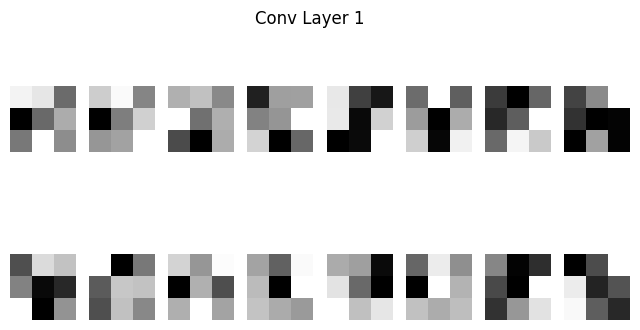

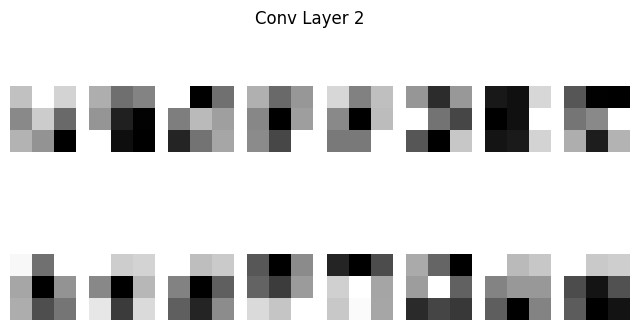

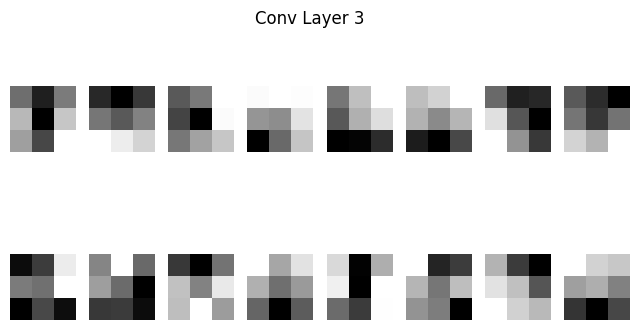

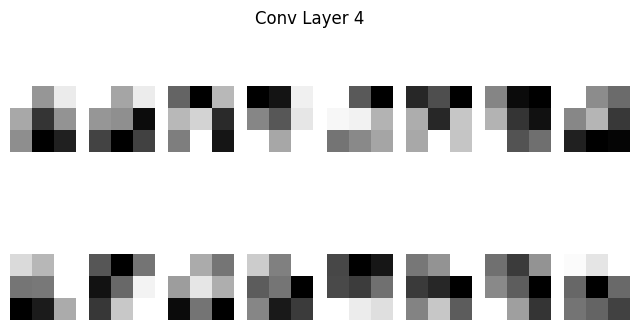

In [59]:
plot_filters(model)

In [70]:
import math

def plot_feature_maps(model, image, max_maps=16):

    model.eval()

    activations = []

    
    def hook_fn(module, input, output):
        activations.append(output.detach())

    hooks = []

    for layer in model.modules():

        if isinstance(layer, nn.Conv2d):

            hook = layer.register_forward_hook(hook_fn)

            hooks.append(hook)

    with torch.no_grad():

        _ = model(image)

    for hook in hooks:
        hook.remove()

    for layer_idx, activation in enumerate(activations):

        activation = activation.squeeze(0).cpu()

        num_maps = min(activation.shape[0], max_maps)

        cols = 4
        rows = math.ceil(num_maps / cols)

        plt.figure(figsize=(12, 3 * rows))

        for i in range(num_maps):

            feature_map = activation[i]

            plt.subplot(rows, cols, i + 1)

            plt.imshow(feature_map, cmap='gray')

            plt.axis('off')

        plt.suptitle(f'Feature Maps - Layer {layer_idx+1}')

        plt.tight_layout()

        plt.show()

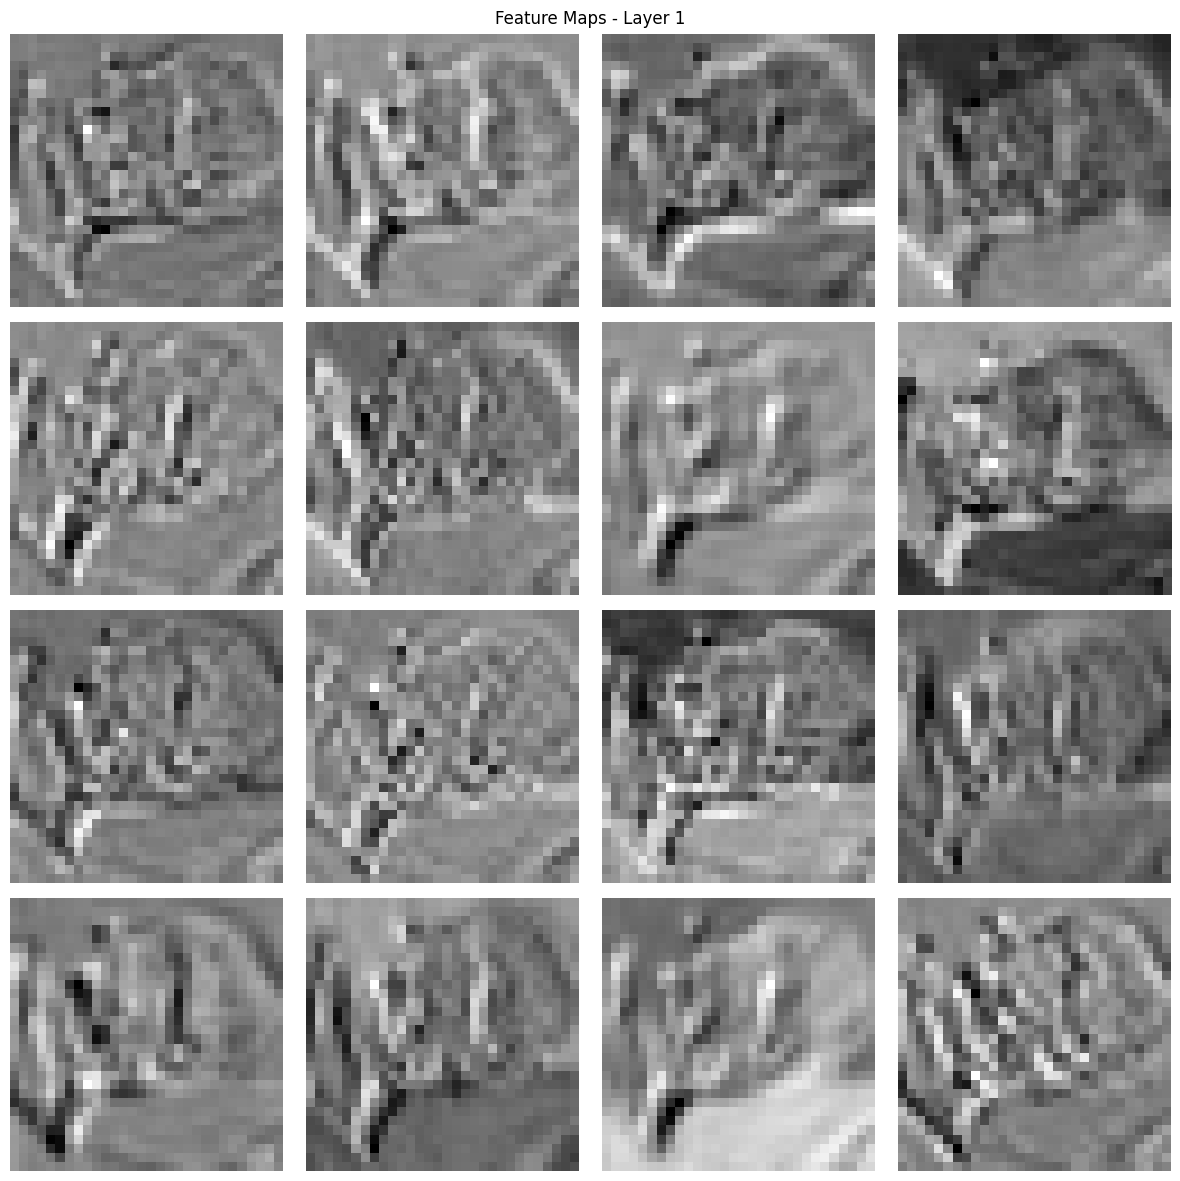

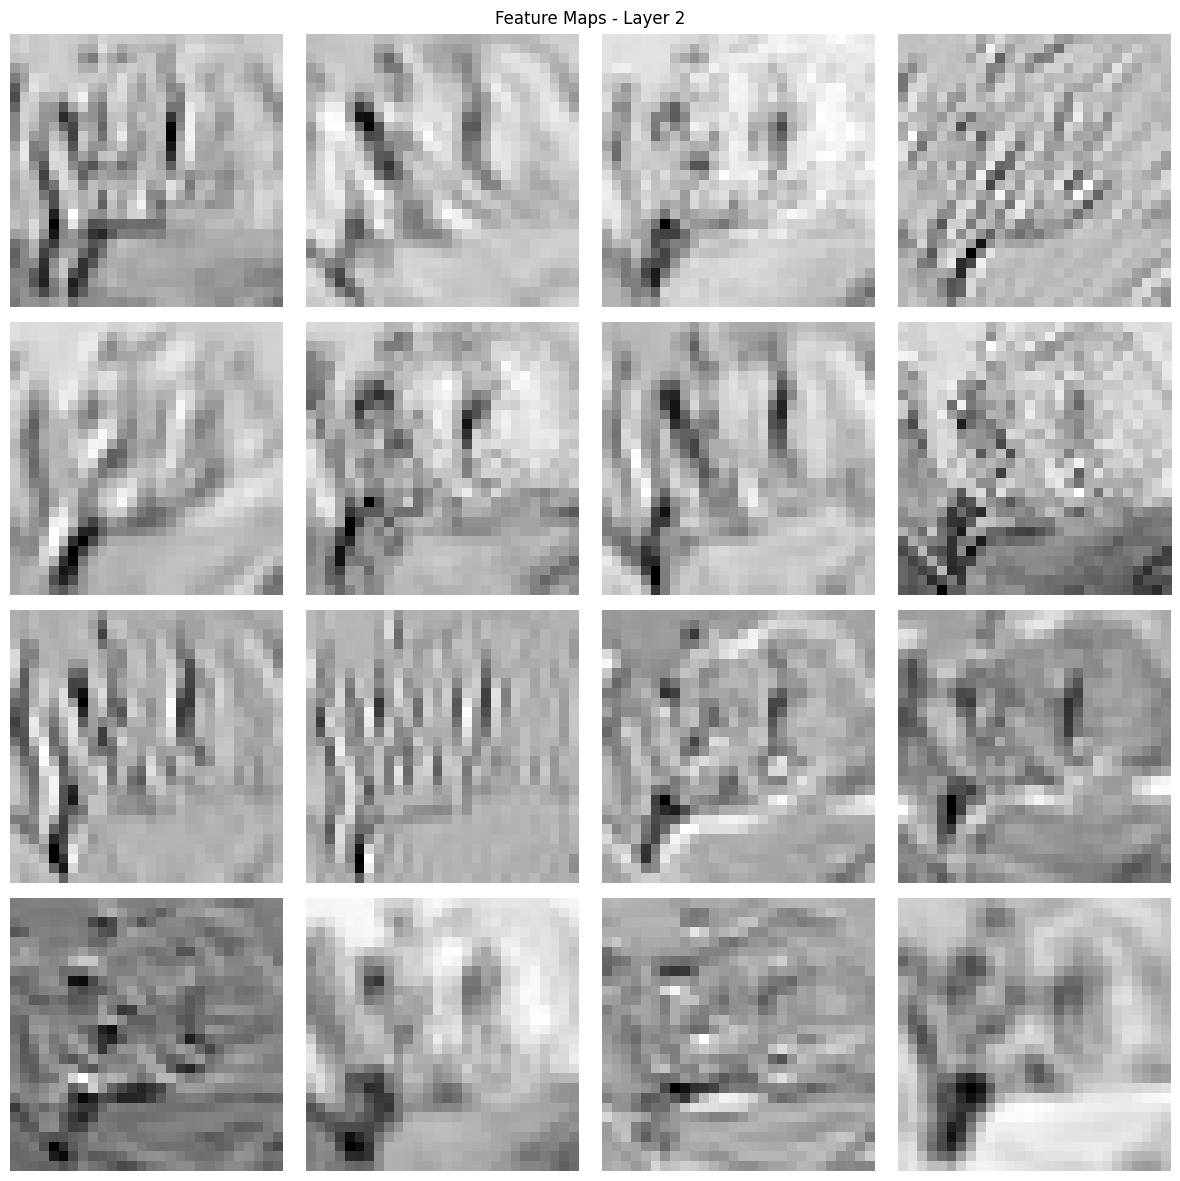

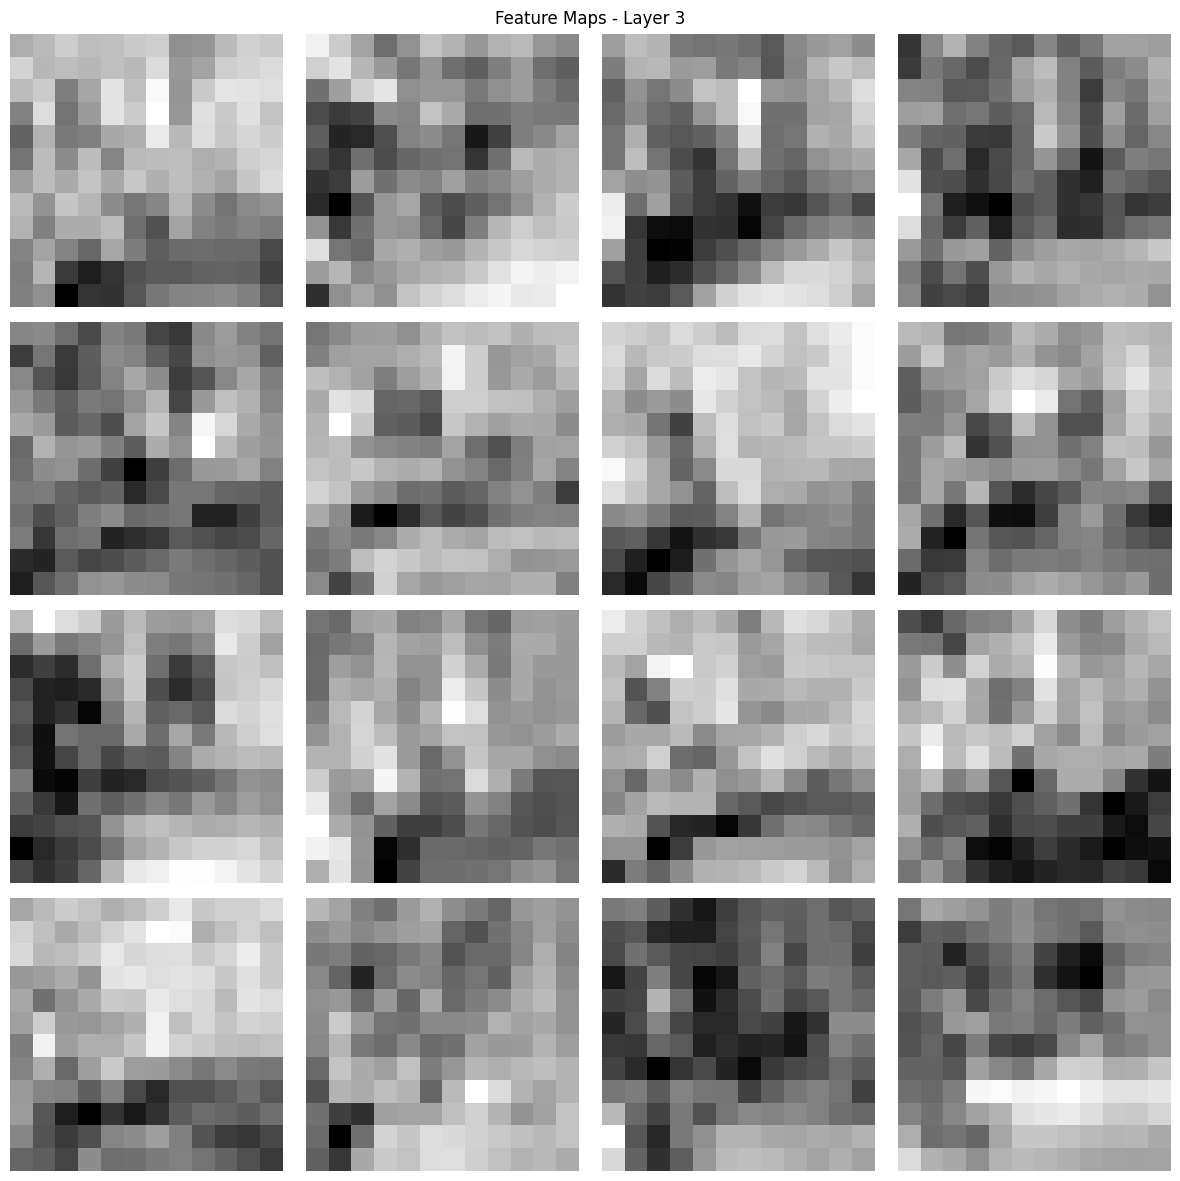

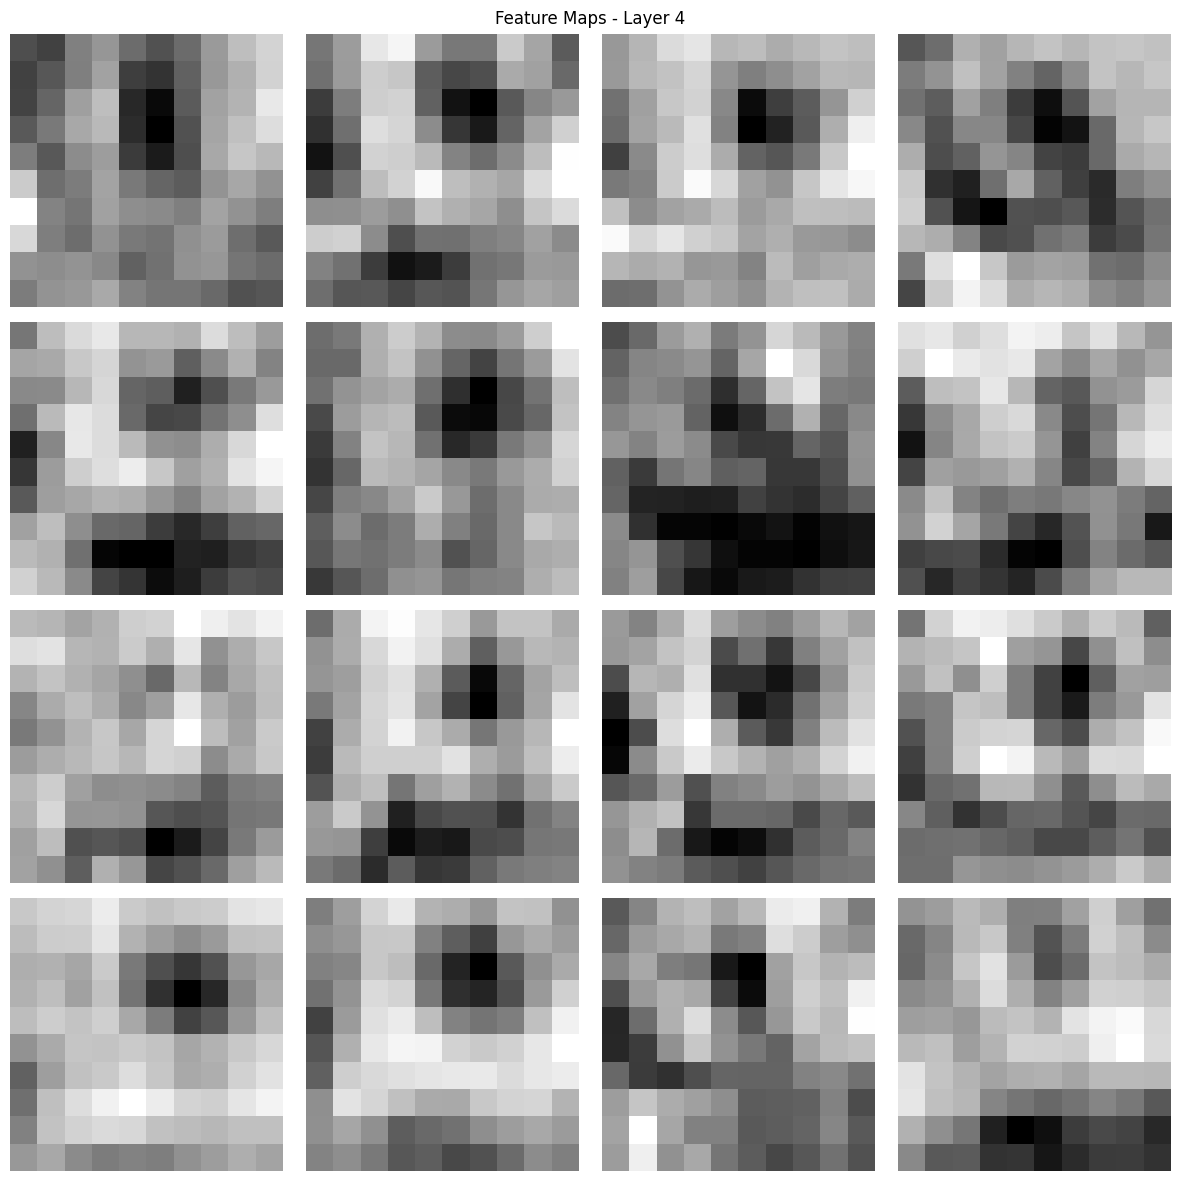

In [71]:
image, label = test_dataset[0]
image = image.to(device)

plot_feature_maps(model, image)

In [72]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def show_predictions(model, dataloader, device, num_images=16):
    model.eval()

    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    images = images.cpu()
    preds = preds.cpu()
    labels = labels.cpu()

    cols = 4
    rows = num_images // cols

    fig, axes = plt.subplots(rows, cols, figsize=(10, 8))
    fig.suptitle("Predictions vs Ground Truth", fontsize=14)

    for i in range(num_images):
        r = i // cols
        c = i % cols

        img = images[i] / 2 + 0.5  # denormalize
        img = np.transpose(img.numpy(), (1,2,0))

        axes[r, c].imshow(img)
        axes[r, c].set_title(
            f"P: {classes[preds[i]]}\nT: {classes[labels[i]]}",
            fontsize=9
        )
        axes[r, c].axis('off')

    plt.tight_layout()
    plt.show()

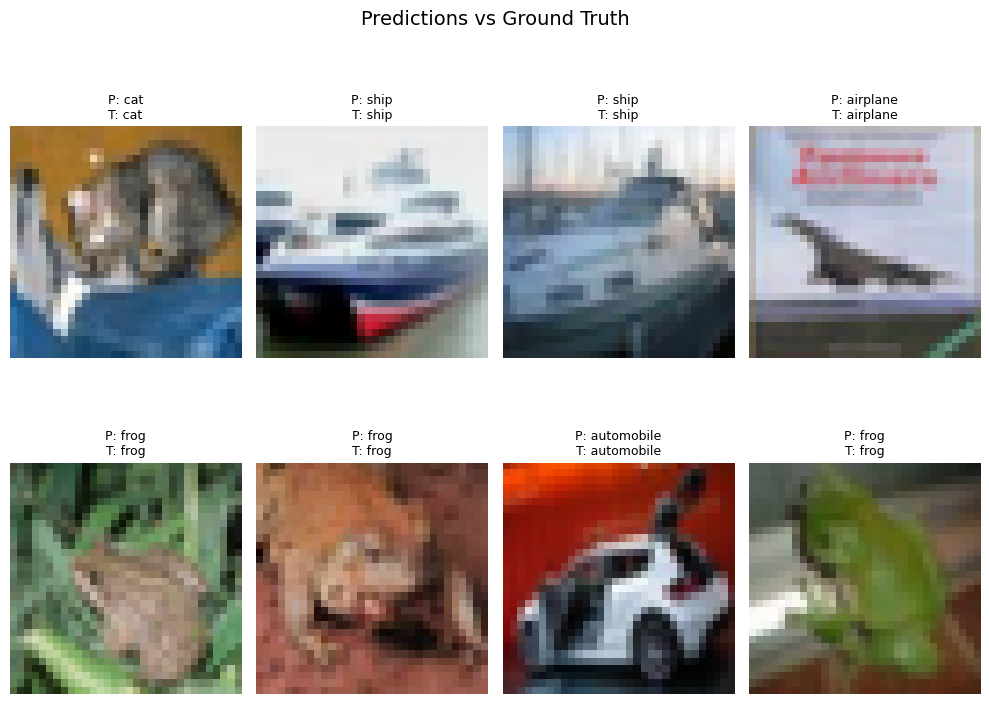

In [75]:
show_predictions(model, test_loader, device, num_images=8)